# SDG Project - Analisi Esplorativa del Dataset
- Caricamento del dataset
- Descrizione del dataset
- Data Cleaning (gestione dei missing values) 
- 

In [1]:
# Import delle librerie principali
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento dei dataset
# Nota: dataset.csv utilizza ';' come separatore e ',' come separatore decimale per i valori numerici
df = pd.read_csv('dataset/dataset.csv', sep=';', decimal=',')
data_desc = pd.read_csv('dataset/data_descriptions.csv', sep=';')

print("Dataset caricati con successo!")

Dataset caricati con successo!


### 1. Descrizione dataset 
Verifichiamo la dimensione complessiva del dataset (numero di righe e colonne) e analizziamo i tipi di dato (`dtypes`) associati a ciascuna colonna.
Separiamo le colonne del dataset in **categoriche** (identificate dal tipo `object`/`string` o dal prefisso `text_format` nelle descrizioni) e **numeriche**. Eseguiamo infine `.describe()` separatamente per i due gruppi.

In [2]:
from IPython.display import display
# 1. Shape del dataset (righe, colonne)
print(f"Shape del dataset: {df.shape[0]} righe, {df.shape[1]} colonne\n")

# Prime 5 righe
print("--- Prime 5 righe del dataset ---")
display(df.head())

# Tipi di dato delle colonne (dtypes)
# print("\n--- Tipi di dato (dtypes) - Prime 20 colonne ---")
# display(df.dtypes.to_frame(name='dtype').head(20))

# Elenco variabili con prefisso text_format nelle descrizioni
tf_vars = set(data_desc[data_desc['Variable'].astype(str).str.startswith('text_format')]['Variable'].astype(str).str.replace('text_format', '').str.lower())

# Classificazione colonne categoriche vs numeriche
cat_cols = [c for c in df.columns if str(df[c].dtype) in ['object', 'string', 'str'] or c.lower() in tf_vars]
num_cols = [c for c in df.columns if c not in cat_cols]

print(f"Numero Colonne Categoriche: {len(cat_cols)}")
# print(f"Colonne Categoriche: {cat_cols}\n")
print(f"Numero Colonne Numeriche: {len(num_cols)}\n")

# print("--- Describe Colonne Numeriche (Prime 10) ---")
# display(df[num_cols].describe().T.head(10))

# print("\n--- Describe Colonne Categoriche ---")
# display(df[cat_cols].describe().T)

# Numero di categorie uniche per ogni colonna categorica
cat_summary = pd.DataFrame({
    'colonna': cat_cols,
    'n_categorie': [df[c].nunique(dropna=True) for c in cat_cols],
    'n_missing': [df[c].isna().sum() for c in cat_cols]
}).sort_values('n_categorie', ascending=False).reset_index(drop=True)

print(f"--- Numero di categorie per ciascuna delle {len(cat_cols)} colonne categoriche ---")
display(cat_summary)

for c in cat_cols:
    n = df[c].nunique(dropna=True)
    if n <= 15:  # mostra i valori solo se sono "gestibili"
        print(f"{c} ({n} categorie): {sorted(df[c].dropna().unique().tolist())}")
    else:
        print(f"{c} ({n} categorie): troppe per l'elenco, es. {df[c].dropna().unique()[:5].tolist()}...")

Shape del dataset: 100000 righe, 100 colonne

--- Prime 5 righe del dataset ---


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,0.0,I,U,U,U,U,U,Y,434.0,1000005


Numero Colonne Categoriche: 21
Numero Colonne Numeriche: 79

--- Numero di categorie per ciascuna delle 21 colonne categoriche ---


,colonna,n_categorie,n_missing
0,crclscod,54,0
1,area,19,40
2,ethnic,17,1732
3,dwllsize,15,38308
4,HHstatin,6,37923
5,marital,5,1732
6,prizm_social_one,5,7388
7,dualband,4,1
8,new_cell,3,0
9,hnd_webcap,3,10189


new_cell (3 categorie): ['N', 'U', 'Y']
crclscod (54 categorie): troppe per l'elenco, es. ['A', 'EA', 'C', 'B', 'BA']...
asl_flag (2 categorie): ['N', 'Y']
prizm_social_one (5 categorie): ['C', 'R', 'S', 'T', 'U']
area (19 categorie): troppe per l'elenco, es. ['NORTHWEST/ROCKY MOUNTAIN AREA', 'CHICAGO AREA', 'GREAT LAKES AREA', 'NEW ENGLAND AREA', 'DALLAS AREA']...
dualband (4 categorie): ['N', 'T', 'U', 'Y']
refurb_new (2 categorie): ['N', 'R']
hnd_webcap (3 categorie): ['UNKW', 'WC', 'WCMB']
ownrent (2 categorie): ['O', 'R']
dwlltype (2 categorie): ['M', 'S']
marital (5 categorie): ['A', 'B', 'M', 'S', 'U']
infobase (2 categorie): ['M', 'N']
HHstatin (6 categorie): ['A', 'B', 'C', 'G', 'H', 'I']
dwllsize (15 categorie): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O']
ethnic (17 categorie): troppe per l'elenco, es. ['N', 'Z', 'U', 'I', 'S']...
kid0_2 (2 categorie): ['U', 'Y']
kid3_5 (2 categorie): ['U', 'Y']
kid6_10 (2 categorie): ['U', 'Y']
kid11_15 (2 cat

### 2. Distribuzione della Colonna Target "churn"
Analizziamo la distribuzione della variabile target `churn` sia in termini di frequenza assoluta che percentuale, per verificare il bilanciamento delle classi (presenza di eventuale class imbalance).
Classe 1 clienti abbandonano il servizio, classe 0 no.

In [3]:
# Conteggio assoluto e percentuale della variabile target churn
churn_counts = df['churn'].value_counts(dropna=False)
churn_pct = df['churn'].value_counts(normalize=True, dropna=False) * 100

churn_dist = pd.DataFrame({
    'Conteggio Assoluto': churn_counts,
    'Percentuale (%)': churn_pct.round(2)
})

display(churn_dist)

# Valutazione del bilanciamento
pct_0, pct_1 = churn_pct.get(0, 0), churn_pct.get(1, 0)
print(f"\nDistribuzione target: Classe 0 = {pct_0:.2f}%, Classe 1 = {pct_1:.2f}%")
if abs(pct_0 - pct_1) < 10:
    print("Esito: La variabile target 'churn' risulta perfettamente bilanciata (~50% vs ~50%).")
else:
    print("Esito: La variabile target 'churn' risulta sbilanciata.")

,Conteggio Assoluto,Percentuale (%)
churn,,
0,50438,50.44
1,49562,49.56



Distribuzione target: Classe 0 = 50.44%, Classe 1 = 49.56%
Esito: La variabile target 'churn' risulta perfettamente bilanciata (~50% vs ~50%).


### 3. Splitto il dataset in train e test
Lo suddivido in modo randomico 70% train e 30% test. 
La popolazione è rappresentata in entrambi i dataset? Dovrei suddividere bilanciando la classe churn nei due dataset?

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Creo una copia di df da usare per lo split
df_clean = df.copy()

# Controllo il formato delle colonne 
print(df_clean.dtypes)

#Imposto Customer_ID come colonna indice 
df_clean = df_clean.set_index('Customer_ID')

# Split in train e test set
X = df_clean.drop(columns=['churn'])  
y = df_clean['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Numero di righe in train e test set
print(f"Dimensione training set: {X_train.shape[0]} righe")
print(f"Dimensione test set: {X_test.shape[0]} righe")

# Verifica che la somma corrisponda al dataset originale
print(f"Somma train + test: {X_train.shape[0] + X_test.shape[0]}")
print(f"Dimensione dataset originale (X): {X.shape[0]} righe")
print(f"Corrispondenza: {X_train.shape[0] + X_test.shape[0] == X.shape[0]}")

# Controllo anche sulle y (dovrebbero combaciare)
print(f"\nDimensione y_train: {y_train.shape[0]}")
print(f"Dimensione y_test: {y_test.shape[0]}")



rev_Mean       float64
mou_Mean       float64
totmrc_Mean    float64
da_Mean        float64
ovrmou_Mean    float64
                ...   
kid11_15           str
kid16_17           str
creditcd           str
eqpdays        float64
Customer_ID      int64
Length: 100, dtype: object
Dimensione training set: 70000 righe
Dimensione test set: 30000 righe
Somma train + test: 100000
Dimensione dataset originale (X): 100000 righe
Corrispondenza: True

Dimensione y_train: 70000
Dimensione y_test: 30000


### 4. Analisi dei Missing Values (MVs)
Calcoliamo il numero di missing values (`null/NaN`) per ciascuna colonna.
L'output è ordinato in modo decrescente e include esclusivamente le colonne con un numero di valori mancanti superiore a zero (`missing > 0`).

Impostiamo una soglia del 30% e attuiamo la strategia di gestione dei MVs:

**Numeriche**
MVs > 30%: Rimozione colonna
MVs < 30%: Imputazione con mediana

**Categoriche**
Categoria ‘MISSING’


In [5]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class MissingValueHandler(BaseEstimator, TransformerMixin):
    """
    Gestisce i missing values secondo la strategia:
    - Colonne numeriche/categoriche con MVs > soglia: rimosse
    - Colonne numeriche con MVs <= soglia: imputate con la mediana (calcolata sul train)
    - Colonne categoriche con MVs <= soglia: imputate con 'MISSING'
    """
    def __init__(self, threshold=30):
        self.threshold = threshold

    def fit(self, X, y=None):
        X = X.copy()
        missing_pct = (X.isnull().sum() / len(X)) * 100
        num_cols = X.select_dtypes(include=[np.number]).columns
        cat_cols = X.select_dtypes(include=['object', 'string']).columns

        num_gt30 = missing_pct[(missing_pct.index.isin(num_cols)) & (missing_pct > self.threshold)]
        cat_gt30 = missing_pct[(missing_pct.index.isin(cat_cols)) & (missing_pct > self.threshold)]

        self.cols_to_drop_ = num_gt30.index.tolist() + cat_gt30.index.tolist()

        remaining_num_cols = [c for c in num_cols if c not in self.cols_to_drop_]
        self.medians_ = {col: X[col].median() for col in remaining_num_cols}
        self.remaining_cat_cols_ = [c for c in cat_cols if c not in self.cols_to_drop_]

        return self

    def transform(self, X):
        X = X.copy()
        X = X.drop(columns=[c for c in self.cols_to_drop_ if c in X.columns])
        for col, median_value in self.medians_.items():
            if col in X.columns:
                X[col] = X[col].fillna(median_value)
        for col in self.remaining_cat_cols_:
            if col in X.columns:
                X[col] = X[col].fillna('MISSING')
        return X


### 5. Preprocessing dentro la Pipeline (niente più fit manuale fuori)
# NB: qui costruiamo solo la STRUTTURA del preprocessor.
# Le colonne categoriche/numeriche verranno individuate DENTRO la pipeline,
# quindi usiamo un piccolo trucco: selezioniamo le colonne per dtype
# direttamente su X_train grezzo (prima della rimozione MVs), che è sufficiente
# perché OneHotEncoder(handle_unknown='ignore') gestisce comunque le colonne mancanti/nuove.

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder

# Usiamo make_column_selector per selezionare le colonne categoriche dinamicamente
# DOPO l'esecuzione di MissingValueHandler nella Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            make_column_selector(dtype_include=['object', 'string']),
        )
    ],
    remainder='passthrough',  # le numeriche passano invariate
)


### 5. Random Forest
Voglio capire quali variabili sono più significative per il churn e lavorare su quelle.


In [6]:
### 6. Pipeline completa: MissingValueHandler + Preprocessor + RandomForest
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

full_pipeline = Pipeline([
    ('missing_handler', MissingValueHandler(threshold=30)),
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=1))
])

# --- Stratified K-Fold (k=5) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Griglia di iperparametri del RF da esplorare ---
param_grid = {
    'rf__n_estimators': [200, 300],
    'rf__max_depth': [5, 10, 15],
    'rf__min_samples_leaf': [1, 5, 10],
    'rf__min_samples_split': [2, 10, 20]
}

# --- Grid Search con cross-validation, prova tutte le ipercombinazioni---
grid_search = GridSearchCV(
    full_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring='f1',       # metrica orientata a individuare bene la classe churn=1
    n_jobs=-1,
    verbose=2,
    return_train_score=True  # utile per controllare l'overfitting per combinazione
)

# Fit: qui passiamo X_train "grezzo", NON processato a mano.
# Il preprocessing viene rifatto da zero ad ogni fold, evitando data leakage.
grid_search.fit(X_train, y_train)

print("Migliori iperparametri trovati:")
print(grid_search.best_params_)
print(f"\nMiglior F1-score medio in CV: {grid_search.best_score_:.4f}")

# --- Ispezione rapida dei risultati per controllare overfitting ---
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results.sort_values('mean_test_score', ascending=False)
display(cv_results_sorted[[
    'param_rf__n_estimators', 'param_rf__max_depth',
    'param_rf__min_samples_leaf', 'param_rf__min_samples_split',
    'mean_train_score', 'mean_test_score', 'std_test_score'
]].head(10))


### 7. Valutazione finale sul TEST set (mai toccato finora)
best_model = grid_search.best_estimator_

# best_model è già rifittato su TUTTO X_train con i migliori iperparametri
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Accuracy su train (best_model):", best_model.score(X_train, y_train))
print("Accuracy su test (best_model):", best_model.score(X_test, y_test))
print(f"\nROC-AUC su test: {roc_auc_score(y_test, y_proba_test):.4f}")
print("\n--- Classification Report (test set) ---")
print(classification_report(y_test, y_pred_test))
print("\n--- Confusion Matrix (test set) ---")
print(confusion_matrix(y_test, y_pred_test))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=200; total time=  26.6s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=200; total time=  27.0s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=200; total time=  27.2s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=200; total time=  26.9s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=200; total time=  27.2s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=300; total time=  38.7s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=300; total time=  38.8s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=300; total time=  39.2s
[CV] END r

,param_rf__n_estimators,param_rf__max_depth,param_rf__min_samples_leaf,param_rf__min_samples_split,mean_train_score,mean_test_score,std_test_score
45,300,15,5,10,0.853499,0.630774,0.002432
43,300,15,5,2,0.853499,0.630774,0.002432
47,300,15,5,20,0.829197,0.629473,0.001341
44,200,15,5,10,0.852177,0.629441,0.001675
42,200,15,5,2,0.852177,0.629441,0.001675
46,200,15,5,20,0.827955,0.629351,0.002828
39,300,15,1,10,0.876933,0.628789,0.001656
41,300,15,1,20,0.844172,0.628444,0.002930
37,300,15,1,2,0.905427,0.628424,0.002329
53,300,15,10,20,0.810722,0.628305,0.001647


Accuracy su train (best_model): 0.8396714285714286
Accuracy su test (best_model): 0.6229333333333333

ROC-AUC su test: 0.6752

--- Classification Report (test set) ---
              precision    recall  f1-score   support

           0       0.63      0.60      0.62     15131
           1       0.61      0.65      0.63     14869

    accuracy                           0.62     30000
   macro avg       0.62      0.62      0.62     30000
weighted avg       0.62      0.62      0.62     30000


--- Confusion Matrix (test set) ---
[[9080 6051]
 [5261 9608]]


CONTROLLO F1 SCORE ANCHE SUL TRAIN E CONFRONTO PER CONFERMARE O NO OVERFITTING

In [7]:
from sklearn.metrics import f1_score

y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

print("Train F1:", f1_score(y_train, y_pred_train))
print("Test F1:", f1_score(y_test, y_pred_test))

Train F1: 0.8413598134143756
Test F1: 0.6294549266247379


Provo ad agire sulla sogli

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:
    
    y_pred = (y_proba_test >= threshold).astype(int)
    
    results.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    })

threshold_results = pd.DataFrame(results)

display(threshold_results)

/Users/saramedde/Desktop/SDG_GROUP/SDG_Project/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,threshold,precision,recall,f1
0,0.10,0.495650,1.000000,0.662789
1,0.15,0.495766,1.000000,0.662892
2,0.20,0.498356,0.998789,0.664935
3,0.25,0.503836,0.993880,0.668688
4,0.30,0.512827,0.982783,0.673969
5,0.35,0.526440,0.959446,0.679851
6,0.40,0.547929,0.908400,0.683553
7,0.45,0.576357,0.814513,0.675046
8,0.50,0.613577,0.646177,0.629455
9,0.55,0.666384,0.422355,0.517021


ANALISI SULLE SOGLIE DI CLASSIFICAZIONE PER RANDOM FOREST


In [ ]:
optimal_threshold = 0.40
y_pred_optimal = (y_proba_test >= optimal_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_optimal))
print(confusion_matrix(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.75      0.26      0.39     15131
           1       0.55      0.91      0.68     14869

    accuracy                           0.58     30000
   macro avg       0.65      0.59      0.54     30000
weighted avg       0.65      0.58      0.54     30000

[[ 3987 11144]
 [ 1362 13507]]


In [10]:
optimal_threshold = 0.45
y_pred_optimal = (y_proba_test >= optimal_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_optimal))
print(confusion_matrix(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.69      0.41      0.52     15131
           1       0.58      0.81      0.68     14869

    accuracy                           0.61     30000
   macro avg       0.63      0.61      0.60     30000
weighted avg       0.64      0.61      0.60     30000

[[ 6229  8902]
 [ 2758 12111]]


## GRADIENT BOOSTING- per risolvere overfittiing e aumentare le performance

In [11]:
### 8. Confronto con Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ('missing_handler', MissingValueHandler(threshold=30)),
    ('preprocessor', preprocessor),
    ('gb', GradientBoostingClassifier(random_state=42))
])

# Griglia ridotta per stare nei tempi (GBM è più lento del RF a parità di alberi)
gb_param_grid = {
    'gb__n_estimators': [100, 200],
    'gb__max_depth': [3, 5],
    'gb__learning_rate': [0.05, 0.1]
}

gb_grid_search = GridSearchCV(
    gb_pipeline,
    param_grid=gb_param_grid,
    cv=skf,              # stesso StratifiedKFold di prima
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

gb_grid_search.fit(X_train, y_train)  # X_train grezzo, stesso principio di prima

print("Migliori iperparametri GBM:")
print(gb_grid_search.best_params_)
print(f"Miglior F1-score medio in CV: {gb_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Migliori iperparametri GBM:
{'gb__learning_rate': 0.1, 'gb__max_depth': 5, 'gb__n_estimators': 200}
Miglior F1-score medio in CV: 0.6382


Confronto le metriche sul train per valutare overfitting e confrontare con il RF

In [12]:
### 9. Valutazione GBM sul test set (confronto diretto con Random Forest)
gb_best_model = gb_grid_search.best_estimator_

y_pred_gb = gb_best_model.predict(X_test)
y_proba_gb = gb_best_model.predict_proba(X_test)[:, 1]

print("Accuracy train (GBM):", gb_best_model.score(X_train, y_train))
print("Accuracy test (GBM):", gb_best_model.score(X_test, y_test))
print(f"ROC-AUC test (GBM): {roc_auc_score(y_test, y_proba_gb):.4f}")
print("\n--- Classification Report GBM (test set) ---")
print(classification_report(y_test, y_pred_gb))

Accuracy train (GBM): 0.7085285714285714
Accuracy test (GBM): 0.6349333333333333
ROC-AUC test (GBM): 0.6906

--- Classification Report GBM (test set) ---
              precision    recall  f1-score   support

           0       0.64      0.63      0.63     15131
           1       0.63      0.64      0.64     14869

    accuracy                           0.63     30000
   macro avg       0.64      0.64      0.63     30000
weighted avg       0.64      0.63      0.63     30000



Lavoro sulle soglie di classificazione per aumentare le performance ottimizzando RECALL a discapito della precision -> preferisco falsi positivi che falsi negativi (?) 
Scelta da discutere

n.b 
precision = tp/(tp+fp)

recall=tp/(tp+fn)

In [13]:
### 10. Analisi soglie di decisione sul Gradient Boosting
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.95, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_proba_gb >= t).astype(int)
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    recall = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    results.append({
        'threshold': round(t, 2),
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

threshold_df_gb = pd.DataFrame(results)
display(threshold_df_gb)

# Soglia che massimizza F1
best_row = threshold_df_gb.loc[threshold_df_gb['f1'].idxmax()]
print(f"\nSoglia ottimale per F1: {best_row['threshold']:.2f} (F1 = {best_row['f1']:.4f})")

,threshold,precision,recall,f1
0,0.10,0.495980,0.999865,0.663054
1,0.15,0.498806,0.997377,0.665022
2,0.20,0.509161,0.988634,0.672154
3,0.25,0.522433,0.971081,0.679370
4,0.30,0.538225,0.941758,0.684978
5,0.35,0.554208,0.900397,0.686107
6,0.40,0.574816,0.841213,0.682956
7,0.45,0.599020,0.756540,0.668628
8,0.50,0.628485,0.644293,0.636291
9,0.55,0.664001,0.513821,0.579336



Soglia ottimale per F1: 0.35 (F1 = 0.6861)


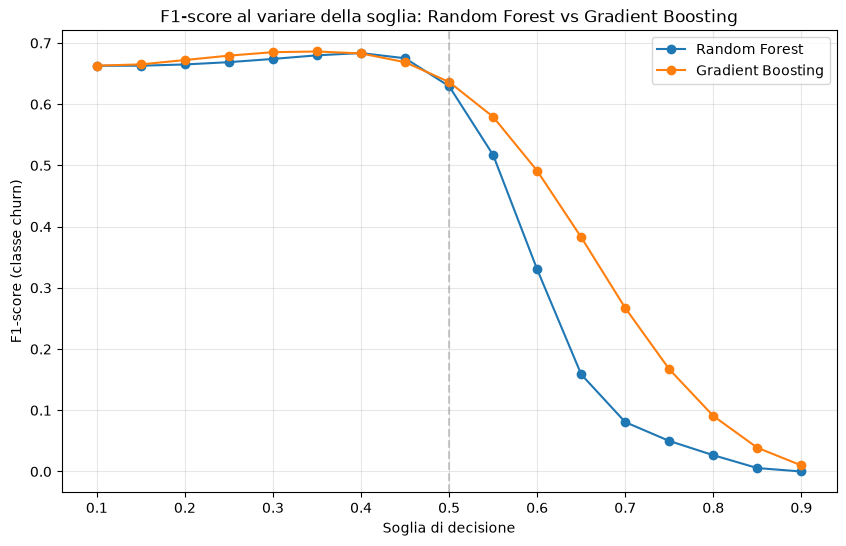

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(threshold_results['threshold'], threshold_results['f1'], marker='o', label='Random Forest')
plt.plot(threshold_df_gb['threshold'], threshold_df_gb['f1'], marker='o', label='Gradient Boosting')
plt.xlabel('Soglia di decisione')
plt.ylabel('F1-score (classe churn)')
plt.title('F1-score al variare della soglia: Random Forest vs Gradient Boosting')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4)
plt.show()

In [16]:
### 11. Permutation Importance sul Gradient Boosting (modello finale)
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

perm_result_gb = permutation_importance(
    gb_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='f1'
)

# CORREZIONE: usa i nomi delle colonne originali di X_test, non quelli del preprocessor
feature_names_gb = X_test.columns

importance_df_gb = pd.DataFrame({
    'Feature': feature_names_gb,
    'Importance_Mean': perm_result_gb.importances_mean,
    'Importance_Std': perm_result_gb.importances_std
}).sort_values(by='Importance_Mean', ascending=False).reset_index(drop=True)

print("--- TOP 20 variabili più importanti (Gradient Boosting) ---")
display(importance_df_gb.head(20))

--- TOP 20 variabili più importanti (Gradient Boosting) ---


,Feature,Importance_Mean,Importance_Std
0,months,0.019238,0.001673
1,eqpdays,0.016492,0.001504
2,change_mou,0.011387,0.001969
3,mou_Mean,0.009242,0.000568
4,hnd_price,0.008379,0.001428
5,totmrc_Mean,0.008159,0.001385
6,mou_rvce_Mean,0.007928,0.000903
7,mou_cvce_Mean,0.006665,0.001342
8,mou_opkv_Mean,0.005621,0.000631
9,change_rev,0.005369,0.001206


### 12. Feature Selection basata su Permutation Importance e Confronto Modelli
Selezioniamo le **Top 25 variabili** a maggior impatto ricavate dalla Permutation Importance sul Gradient Boosting.
Addestriamo il modello sul sottoinsieme ridotto di variabili per verificare se le prestazioni rimangono equivalenti (o migliorano) riducendo drasticamente il rumore e i tempi di calcolo.

In [ ]:
# 1. Selezioniamo le Top 25 feature
top_n = 25
top_features = importance_df_gb['Feature'].head(top_n).tolist()
print(f'--- Top {top_n} Feature Selezionate ---')
print(top_features)

# Subset di train e test set
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# 2. Definiamo la pipeline ridotta per Gradient Boosting
import time
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score

gb_top_pipeline = Pipeline([
    ('missing_handler', MissingValueHandler(threshold=30)),
    ('preprocessor', preprocessor),
    ('gb', GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42))
])

# Misuriamo il tempo di fit
start_time = time.time()
gb_top_pipeline.fit(X_train_top, y_train)
fit_time_top = time.time() - start_time

# Predizioni sul test set
y_pred_top = gb_top_pipeline.predict(X_test_top)
y_proba_top = gb_top_pipeline.predict_proba(X_test_top)[:, 1]

# Performance a soglia standard 0.50
acc_top = accuracy_score(y_test, y_pred_top)
f1_top_50 = f1_score(y_test, y_pred_top)
auc_top = roc_auc_score(y_test, y_proba_top)

# Performance a soglia ottimale 0.35
y_pred_top_35 = (y_proba_top >= 0.40).astype(int)
f1_top_35 = f1_score(y_test, y_pred_top_35)

# 3. Tabella comparativa: Full Model (99 var) vs Top 25 Model
y_pred_full_35 = (y_proba_gb >= 0.35).astype(int)

comparison_df = pd.DataFrame({
    'Metrica': ['Num. Feature', 'Accuracy (t=0.50)', 'F1-Score (t=0.50)', 'F1-Score (t=0.35)', 'ROC-AUC', 'Tempo Fit (s)'],
    'Modello Full': [
        X_train.shape[1],
        round(accuracy_score(y_test, y_pred_gb), 4),
        round(f1_score(y_test, y_pred_gb), 4),
        round(f1_score(y_test, y_pred_full_35), 4),
        round(roc_auc_score(y_test, y_proba_gb), 4),
        '-'
    ],
    'Modello Top 25': [
        len(top_features),
        round(acc_top, 4),
        round(f1_top_50, 4),
        round(f1_top_35, 4),
        round(auc_top, 4),
        round(fit_time_top, 2)
    ]
})

print('\n--- TABELLA DI CONFRONTO PERFORMANCE ---')
display(comparison_df)

print('\n--- Classification Report Modello Top 25 (Soglia 0.35) ---')
print(classification_report(y_test, y_pred_top_35))


--- Top 25 Feature Selezionate ---
['months', 'eqpdays', 'change_mou', 'mou_Mean', 'hnd_price', 'totmrc_Mean', 'mou_rvce_Mean', 'mou_cvce_Mean', 'mou_opkv_Mean', 'change_rev', 'peak_vce_Mean', 'area', 'mou_peav_Mean', 'refurb_new', 'avg3mou', 'ethnic', 'ovrmou_Mean', 'hnd_webcap', 'crclscod', 'attempt_Mean', 'adjmou', 'da_Mean', 'uniqsubs', 'ovrrev_Mean', 'totrev']

--- TABELLA DI CONFRONTO PERFORMANCE ---


,Metrica,Modello Full,Modello Top 25
0,Num. Feature,98,25.0000
1,Accuracy (t=0.50),0.6349,0.6298
2,F1-Score (t=0.50),0.6363,0.6337
3,F1-Score (t=0.35),0.683,0.6839
4,ROC-AUC,0.6906,0.6838
5,Tempo Fit (s),-,81.6800



--- Classification Report Modello Top 25 (Soglia 0.35) ---
              precision    recall  f1-score   support

           0       0.74      0.28      0.41     15131
           1       0.55      0.90      0.68     14869

    accuracy                           0.59     30000
   macro avg       0.65      0.59      0.55     30000
weighted avg       0.65      0.59      0.54     30000



Stessa cella precedente ma ho incluso confronto delle tre soglie 

In [20]:
import time
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score

# 1. Selezioniamo le Top 25 feature
top_n = 25
top_features = importance_df_gb['Feature'].head(top_n).tolist()
print(f'--- Top {top_n} Feature Selezionate ---')
print(top_features)

# Subset di train e test set
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# 2. Definiamo la pipeline ridotta per Gradient Boosting
gb_top_pipeline = Pipeline([
    ('missing_handler', MissingValueHandler(threshold=30)),
    ('preprocessor', preprocessor),
    ('gb', GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42))
])

# Misuriamo il tempo di fit
start_time = time.time()
gb_top_pipeline.fit(X_train_top, y_train)
fit_time_top = time.time() - start_time

# Predizioni sul test set (probabilità)
y_pred_top_50 = gb_top_pipeline.predict(X_test_top)
y_proba_top = gb_top_pipeline.predict_proba(X_test_top)[:, 1]

# Predizioni per le tre soglie
y_pred_top_40 = (y_proba_top >= 0.40).astype(int)
y_pred_top_35 = (y_proba_top >= 0.35).astype(int)

# Predizioni modello full per le stesse soglie (per confronto omogeneo)
y_pred_full_50 = y_pred_gb
y_pred_full_40 = (y_proba_gb >= 0.40).astype(int)
y_pred_full_35 = (y_proba_gb >= 0.35).astype(int)

# 3. Tabella comparativa sintetica: Full Model (99 var) vs Top 25 Model
comparison_df = pd.DataFrame({
    'Metrica': [
        'Num. Feature', 
        'ROC-AUC', 
        'Accuracy (t=0.50)', 
        'F1-Score (t=0.50)', 
        'F1-Score (t=0.40)', 
        'F1-Score (t=0.35)', 
        'Tempo Fit (s)'
    ],
    'Modello Full (99 Var)': [
        X_train.shape[1],
        round(roc_auc_score(y_test, y_proba_gb), 4),
        round(accuracy_score(y_test, y_pred_full_50), 4),
        round(f1_score(y_test, y_pred_full_50), 4),
        round(f1_score(y_test, y_pred_full_40), 4),
        round(f1_score(y_test, y_pred_full_35), 4),
        '-'
    ],
    'Modello Top 25 (25 Var)': [
        len(top_features),
        round(roc_auc_score(y_test, y_proba_top), 4),
        round(accuracy_score(y_test, y_pred_top_50), 4),
        round(f1_score(y_test, y_pred_top_50), 4),
        round(f1_score(y_test, y_pred_top_40), 4),
        round(f1_score(y_test, y_pred_top_35), 4),
        round(fit_time_top, 2)
    ]
})

print('\n' + '='*50)
print('--- TABELLA DI CONFRONTO GENERALE METRICHE ---')
print('='*50)
display(comparison_df)

# 4. Classification Reports di dettaglio per la soglia finale (Modello Top 25)
print('\n' + '='*50)
print('--- CLASSIFICATION REPORT: SOGLIA 0.50 (STANDARD) ---')
print('='*50)
print(classification_report(y_test, y_pred_top_50, digits=4))

print('\n' + '='*50)
print('--- CLASSIFICATION REPORT: SOGLIA 0.40 (SWEET SPOT) ---')
print('='*50)
print(classification_report(y_test, y_pred_top_40, digits=4))

print('\n' + '='*50)
print('--- CLASSIFICATION REPORT: SOGLIA 0.35 (HIGH RECALL) ---')
print('='*50)
print(classification_report(y_test, y_pred_top_35, digits=4))

--- Top 25 Feature Selezionate ---
['months', 'eqpdays', 'change_mou', 'mou_Mean', 'hnd_price', 'totmrc_Mean', 'mou_rvce_Mean', 'mou_cvce_Mean', 'mou_opkv_Mean', 'change_rev', 'peak_vce_Mean', 'area', 'mou_peav_Mean', 'refurb_new', 'avg3mou', 'ethnic', 'ovrmou_Mean', 'hnd_webcap', 'crclscod', 'attempt_Mean', 'adjmou', 'da_Mean', 'uniqsubs', 'ovrrev_Mean', 'totrev']

--- TABELLA DI CONFRONTO GENERALE METRICHE ---


,Metrica,Modello Full (99 Var),Modello Top 25 (25 Var)
0,Num. Feature,98,25.0000
1,ROC-AUC,0.6906,0.6838
2,Accuracy (t=0.50),0.6349,0.6298
3,F1-Score (t=0.50),0.6363,0.6337
4,F1-Score (t=0.40),0.683,0.6815
5,F1-Score (t=0.35),0.6861,0.6839
6,Tempo Fit (s),-,82.7300



--- CLASSIFICATION REPORT: SOGLIA 0.50 (STANDARD) ---
              precision    recall  f1-score   support

           0     0.6383    0.6138    0.6258     15131
           1     0.6217    0.6460    0.6337     14869

    accuracy                         0.6298     30000
   macro avg     0.6300    0.6299    0.6297     30000
weighted avg     0.6301    0.6298    0.6297     30000


--- CLASSIFICATION REPORT: SOGLIA 0.40 (SWEET SPOT) ---
              precision    recall  f1-score   support

           0     0.7125    0.3711    0.4880     15131
           1     0.5698    0.8476    0.6815     14869

    accuracy                         0.6073     30000
   macro avg     0.6411    0.6093    0.5847     30000
weighted avg     0.6418    0.6073    0.5839     30000


--- CLASSIFICATION REPORT: SOGLIA 0.35 (HIGH RECALL) ---
              precision    recall  f1-score   support

           0     0.7407    0.2809    0.4073     15131
           1     0.5515    0.8999    0.6839     14869

    accuracy

Confusion Matrix delle tre soglie

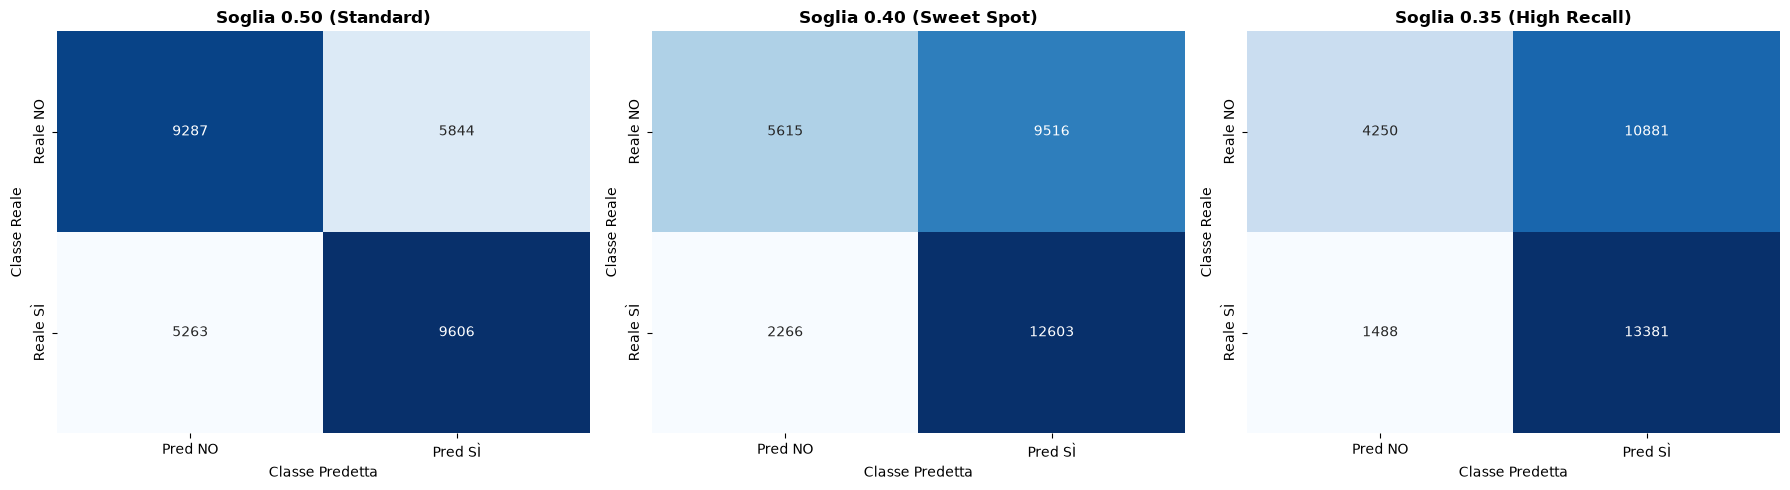

=== SOGLIA 0.50 (STANDARD) ===
True Negatives  (Correttamente NON Churn): 9287
False Positives (Falsi Allarmi / Spreco): 5844
False Negatives (Persi / Churn non presi): 5263
True Positives  (Correttamente Churn):     9606

=== SOGLIA 0.40 (SWEET SPOT) ===
True Negatives  (Correttamente NON Churn): 5615
False Positives (Falsi Allarmi / Spreco): 9516
False Negatives (Persi / Churn non presi): 2266
True Positives  (Correttamente Churn):     12603

=== SOGLIA 0.35 (HIGH RECALL) ===
True Negatives  (Correttamente NON Churn): 4250
False Positives (Falsi Allarmi / Spreco): 10881
False Negatives (Persi / Churn non presi): 1488
True Positives  (Correttamente Churn):     13381



In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Calcoliamo le matrici di confusione per le 3 soglie
cm_50 = confusion_matrix(y_test, y_pred_top_50)
cm_40 = confusion_matrix(y_test, y_pred_top_40)
cm_35 = confusion_matrix(y_test, y_pred_top_35)

# 2. Plot visivo affiancato per la presentazione
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

soglie_cm = [
    (cm_50, "Soglia 0.50 (Standard)"),
    (cm_40, "Soglia 0.40 (Sweet Spot)"),
    (cm_35, "Soglia 0.35 (High Recall)")
]

for ax, (cm, titolo) in zip(axes, soglie_cm):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Pred NO', 'Pred SÌ'],
                yticklabels=['Reale NO', 'Reale SÌ'])
    ax.set_title(titolo, fontsize=12, fontweight='bold')
    ax.set_ylabel('Classe Reale')
    ax.set_xlabel('Classe Predetta')

plt.tight_layout()
plt.show()

# 3. Stampa testuale dei valori numerici (TN, FP, FN, TP)
for cm, titolo in soglie_cm:
    tn, fp, fn, tp = cm.ravel()
    print(f"=== {titolo.upper()} ===")
    print(f"True Negatives  (Correttamente NON Churn): {tn}")
    print(f"False Positives (Falsi Allarmi / Spreco): {fp}")
    print(f"False Negatives (Persi / Churn non presi): {fn}")
    print(f"True Positives  (Correttamente Churn):     {tp}\n")

### 13. Visualizzazioni Grafiche di Valutazione del Modello
Generiamo i grafici per valutare la capacità discriminativa del modello Gradient Boosting ridotto (Top 25 feature):
- **Curva ROC-AUC**
- **Curva Precision-Recall** (con indicazione della soglia ottimale a 0.35)
- **Heatmap della Matrice di Confusione** (soglia 0.35)

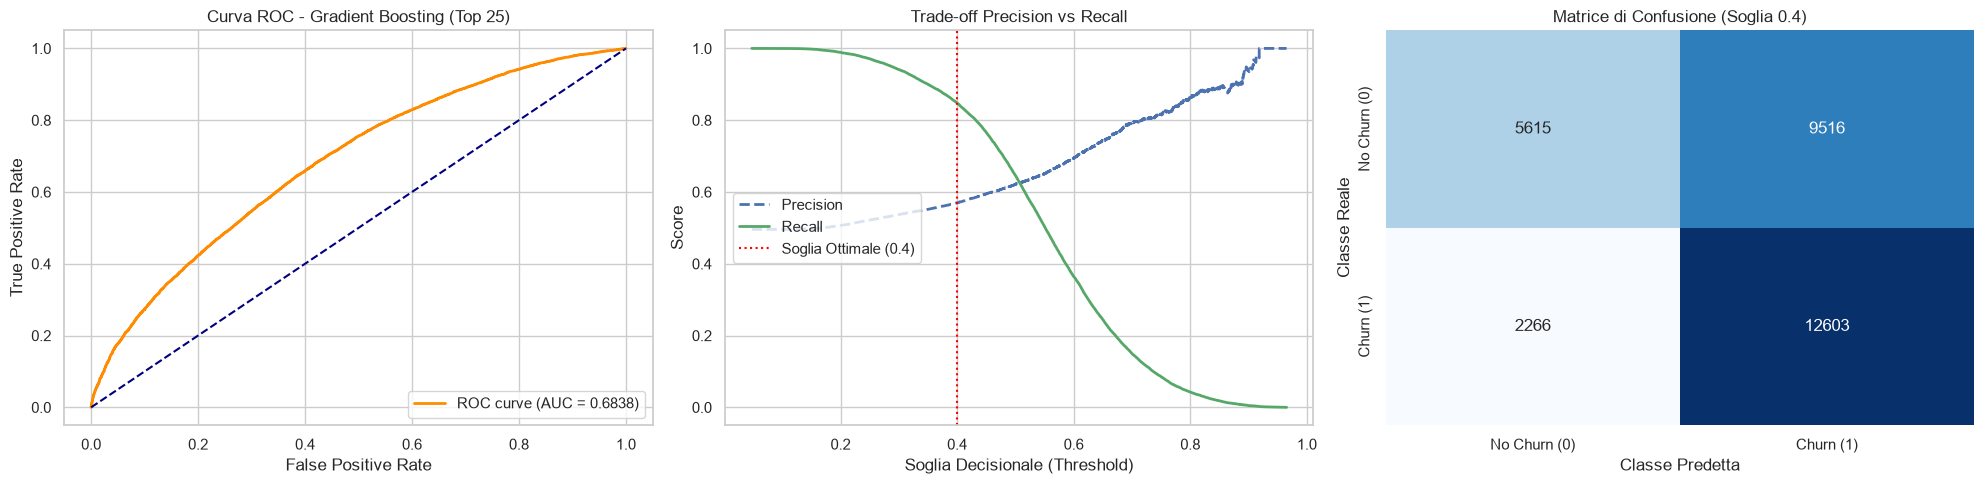

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score

# Configurazione stile grafico
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_top)
auc_score_val = roc_auc_score(y_test, y_proba_top)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score_val:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC - Gradient Boosting (Top 25)')
axes[0].legend(loc='lower right')

# 2. Curva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_top)
axes[1].plot(thresholds, precisions[:-1], 'b--', label='Precision', lw=2)
axes[1].plot(thresholds, recalls[:-1], 'g-', label='Recall', lw=2)
axes[1].axvline(x=0.4, color='red', linestyle=':', label='Soglia Ottimale (0.4)')
axes[1].set_xlabel('Soglia Decisionale (Threshold)')
axes[1].set_ylabel('Score')
axes[1].set_title('Trade-off Precision vs Recall')
axes[1].legend(loc='center left')

# 3. Heatmap Matrice di Confusione (Soglia 0.40)
cm = confusion_matrix(y_test, y_pred_top_40)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], cbar=False,
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
axes[2].set_xlabel('Classe Predetta')
axes[2].set_ylabel('Classe Reale')
axes[2].set_title('Matrice di Confusione (Soglia 0.4)')

plt.tight_layout()
plt.show()

### 14. Spiegabilità del Modello tramite SHAP (SHapley Additive exPlanations)
Utilizziamo la libreria **SHAP** per analizzare il contributo causale di ciascuna variabile sulle predizioni del modello:
- **Summary Plot (Beeswarm)**: Mostra l'impatto direzionale (se un valore alto/basso di una variabile aumenta o diminuisce la probabilità di Churn).
- **Bar Plot**: Classifica la rilevanza globale media assoluta di ciascuna variabile.

--- SHAP Summary Plot (Impatti Direzionali sul Churn) ---


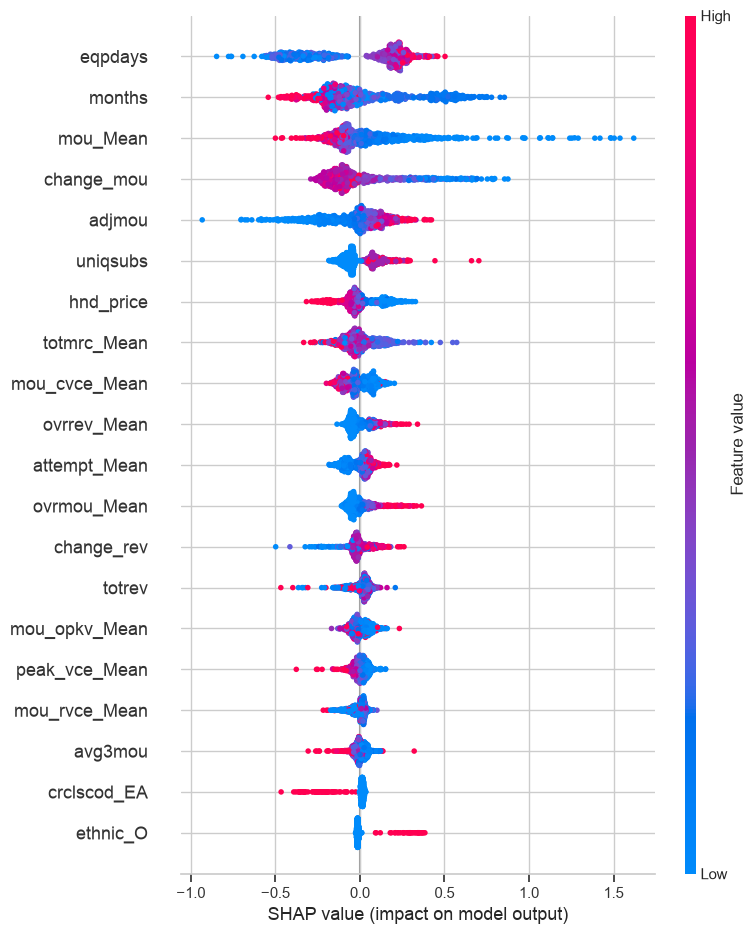

--- SHAP Bar Plot (Importanza Globale Media) ---


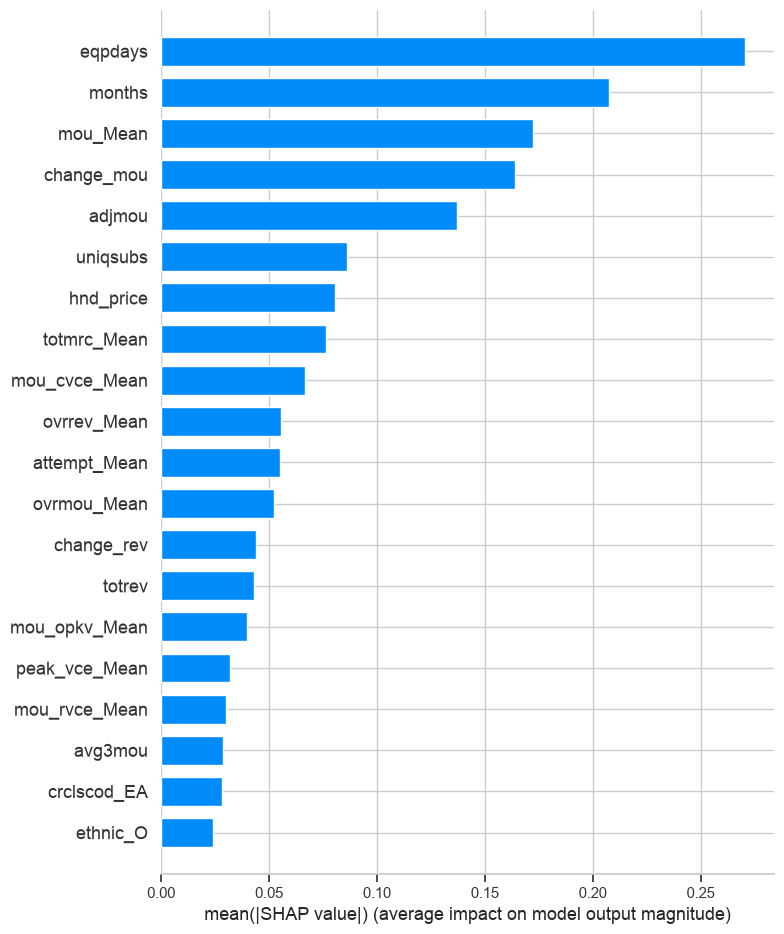

In [27]:
import numpy as np
import shap

# 1. Preprocessing del dataset di test tramite la pipeline
X_test_mh = gb_top_pipeline.named_steps['missing_handler'].transform(
    X_test_top
)
X_test_trans = gb_top_pipeline.named_steps['preprocessor'].transform(
    X_test_mh
)

# Converti in array denso se il preprocessor ha restituito una matrice sparsa
if hasattr(X_test_trans, 'toarray'):
  X_test_trans = X_test_trans.toarray()
else:
  X_test_trans = np.asarray(X_test_trans, dtype=np.float64)

feature_names_out = [
    f.replace('cat__', '').replace('remainder__', '')
    for f in gb_top_pipeline.named_steps[
        'preprocessor'
    ].get_feature_names_out()
]

# 2. Calcolo degli SHAP Values su un campione rappresentativo (1.000 campioni)
explainer = shap.TreeExplainer(gb_top_pipeline.named_steps['gb'])
shap_sample = X_test_trans[:1000]
shap_values = explainer(shap_sample)

# 3. Visualizzazione Grafici
print('--- SHAP Summary Plot (Impatti Direzionali sul Churn) ---')
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, shap_sample, feature_names=feature_names_out, show=True
)

print('--- SHAP Bar Plot (Importanza Globale Media) ---')
plt.figure(figsize=(12, 6))
shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_names_out,
    plot_type='bar',
    show=True,
)